# SLALOM: R vs Python Implementation Comparison

This notebook validates the pecotmr R implementation of SLALOM against the original Python
implementation from [`slalom.py`](https://github.com/mkanai/slalom/blob/master/slalom.py).

SLALOM computes:
1. **Approximate Bayes Factors (ABF)** and posterior inclusion probabilities
2. **Credible sets** (95% and 99%)
3. **DENTIST-S statistic** relative to a lead variant for outlier detection

We use a subset of the DENTIST toy dataset (chr22, ~600 variants) included with pecotmr.

### Bug fix: Lead variant selection

The original R implementation used two-sided p-values (`2 * pnorm(abs(z), lower.tail=FALSE)`)
to select the lead variant, while the Python original uses one-sided p-values (`stats.norm.cdf(z)`).
This was fixed to use `pnorm(zScore)` to match the Python behavior.

## 1. Setup and Data Preparation

In [1]:
devtools::load_all("/home/gw/GIT/pecotmr")
library(data.table)

# Use toy data from pecotmr
extdata_dir <- "/home/gw/GIT/pecotmr/inst/extdata"
bfile <- file.path(extdata_dir, "toy_ref")
sumstat <- fread(file.path(extdata_dir, "toy_summary.txt.gz"))
bim <- fread(paste0(bfile, ".bim"), header=FALSE,
             col.names=c("chrom","variant_id","gd","pos","A1","A2"))

# Subset to ~600 variants in a 2Mb region
region_snps <- bim$variant_id[bim$pos <= bim$pos[1] + 2e6]
snp_file <- tempfile(); writeLines(region_snps, snp_file)
sub_bfile <- tempfile(); sub_sumstat <- tempfile()
system(sprintf("plink --bfile %s --extract %s --make-bed --out %s 2>/dev/null",
               bfile, snp_file, sub_bfile))
fwrite(sumstat[sumstat$SNP %in% region_snps,], sub_sumstat, sep="\t", quote=FALSE)

# Get aligned data and LD matrix via dentist_from_files
res <- dentist_from_files(sub_sumstat, sub_bfile, nSample=NULL, nIter=8, verbose=FALSE)
z <- res$sum_stat$z
LD <- res$LD_mat
cat(sprintf("Test data: %d variants\n", length(z)))

# Save z-scores and LD to temp files for Python
z_file <- tempfile(fileext=".csv")
ld_file <- tempfile(fileext=".csv")
py_out  <- tempfile(fileext=".csv")
write(z, z_file, ncolumns=1)
write.table(LD, ld_file, sep=",", row.names=FALSE, col.names=FALSE)
cat(sprintf("Saved z-scores to %s\n", z_file))
cat(sprintf("Saved LD matrix to %s\n", ld_file))

ℹ Loading pecotmr


Warning message:
“replacing previous import ‘vroom::cols’ by ‘readr::cols’ when loading ‘pecotmr’”



Attaching package: ‘data.table’




The following objects are masked from ‘package:pecotmr’:

    between, first, last




Rows: 608 Columns: 6


...

Warning message in dentist_single_window(sum_stat$z, R = LD_mat, nSample = nSample, :
“The number of variants is below 2000. The algorithm may not work as expected, as suggested by the original DENTIST.”


98 duplicated variants out of a total of 608 were found at r threshold of 0.995



Test data: 608 variants


Saved z-scores to /tmp/RtmpAh5DtO/filee9cb31f323d59.csv


Saved LD matrix to /tmp/RtmpAh5DtO/filee9cb36ab89a3c.csv


## 2. Run Python SLALOM

We run the reference Python implementation extracted from the original `slalom.py`.
The key functions (`abf`, `get_cs`, DENTIST-S computation) are copied verbatim.

In [2]:
py_script <- "/home/gw/GIT/pecotmr/inst/prototype/slalom_python_reference.py"
cmd <- sprintf("python3 %s %s %s %s 2>&1", py_script, z_file, ld_file, py_out)
py_stdout <- system(cmd, intern=TRUE)
cat("Python output:\n")
cat(paste(py_stdout, collapse="\n"), "\n")

# Parse summary values
py_summary <- list()
for (line in py_stdout) {
  parts <- strsplit(line, "=")[[1]]
  if (length(parts) == 2) py_summary[[parts[1]]] <- parts[2]
}

# Load per-variant results
py_df <- read.csv(py_out)
cat(sprintf("\nPython results: %d rows\n", nrow(py_df)))

Python output:


/home/gw/GIT/pecotmr/inst/prototype/slalom_python_reference.py:81: RuntimeWarning: invalid value encountered in divide
  t_dentist_s = (z - r_lead * lead_z) ** 2 / (1 - r2_lead)
lead_idx=48
n_r2=2
n_dentist_s_outlier=1
max_pip=4.658015153899550e-03
cs_95_size=577
cs_99_size=602 



Python results: 608 rows


## 3. Run R SLALOM

In [3]:
r_result <- slalom(z, R=LD, nlog10p_dentist_s_threshold=4.0, r2_threshold=0.6)
r_df <- r_result$data

cat("R output:\n")
cat(sprintf("lead_idx=%d\n", r_result$summary$lead_pip_variant - 1))  # 0-based
cat(sprintf("n_r2=%d\n", r_result$summary$n_r2))
cat(sprintf("n_dentist_s_outlier=%d\n", r_result$summary$n_dentist_s_outlier))
cat(sprintf("max_pip=%.15e\n", r_result$summary$max_pip))
cat(sprintf("cs_95_size=%d\n", length(r_result$summary$cs_95)))
cat(sprintf("cs_99_size=%d\n", length(r_result$summary$cs_99)))

R output:


lead_idx=48


n_r2=2


n_dentist_s_outlier=1


max_pip=4.658015719561474e-03


cs_95_size=577


cs_99_size=602


## 4. Compare Summary Statistics

In [4]:
cat("=== Summary Comparison ===\n\n")
cat(sprintf("%-25s %15s %15s %s\n", "Metric", "Python", "R", "Match?"))
cat(paste(rep("-", 70), collapse=""), "\n")

r_lead <- r_result$summary$lead_pip_variant - 1  # 0-based
py_lead <- as.integer(py_summary$lead_idx)
cat(sprintf("%-25s %15d %15d %s\n", "lead_idx (0-based)", py_lead, r_lead,
            ifelse(py_lead == r_lead, "YES", "NO")))

py_nr2 <- as.integer(py_summary$n_r2)
r_nr2 <- r_result$summary$n_r2
cat(sprintf("%-25s %15d %15d %s\n", "n_r2", py_nr2, r_nr2,
            ifelse(py_nr2 == r_nr2, "YES", "NO")))

py_nout <- as.integer(py_summary$n_dentist_s_outlier)
r_nout <- r_result$summary$n_dentist_s_outlier
cat(sprintf("%-25s %15d %15d %s\n", "n_dentist_s_outlier", py_nout, r_nout,
            ifelse(py_nout == r_nout, "YES", "NO")))

py_pip <- as.numeric(py_summary$max_pip)
r_pip <- r_result$summary$max_pip
cat(sprintf("%-25s %15.10f %15.10f %s\n", "max_pip", py_pip, r_pip,
            ifelse(abs(py_pip - r_pip) < 1e-8, "YES", "NO")))

py_cs95 <- as.integer(py_summary$cs_95_size)
r_cs95 <- length(r_result$summary$cs_95)
cat(sprintf("%-25s %15d %15d %s\n", "cs_95 size", py_cs95, r_cs95,
            ifelse(py_cs95 == r_cs95, "YES", "NO")))

py_cs99 <- as.integer(py_summary$cs_99_size)
r_cs99 <- length(r_result$summary$cs_99)
cat(sprintf("%-25s %15d %15d %s\n", "cs_99 size", py_cs99, r_cs99,
            ifelse(py_cs99 == r_cs99, "YES", "NO")))

=== Summary Comparison ===



Metric                             Python               R Match?


---------------------------------------------------------------------- 


lead_idx (0-based)                     48              48 YES


n_r2                                    2               2 YES


n_dentist_s_outlier                     1               1 YES


max_pip                      0.0046580152    0.0046580157 YES


cs_95 size                            577             577 YES


cs_99 size                            602             602 YES


## 5. Compare Per-Variant Results

In [5]:
cat("=== Per-Variant Comparison ===\n\n")

# prob
prob_diff <- abs(py_df$prob - r_df$prob)
cat(sprintf("prob:              max_diff = %.2e  cor = %.15f\n",
            max(prob_diff), cor(py_df$prob, r_df$prob)))

# pvalue
pval_diff <- abs(py_df$pvalue - r_df$pvalue)
cat(sprintf("pvalue:            max_diff = %.2e  cor = %.15f\n",
            max(pval_diff), cor(py_df$pvalue, r_df$pvalue)))

# nlog10p_dentist_s (exclude NaN at lead)
mask <- !is.na(py_df$nlog10p_dentist_s) & !is.na(r_df$nlog10p_dentist_s)
nlog_diff <- abs(py_df$nlog10p_dentist_s[mask] - r_df$nlog10p_dentist_s[mask])
cat(sprintf("nlog10p_dentist_s: max_diff = %.2e  cor = %.15f\n",
            max(nlog_diff),
            cor(py_df$nlog10p_dentist_s[mask], r_df$nlog10p_dentist_s[mask])))

# outlier flags
r_outliers <- r_df$outliers
r_outliers[is.na(r_outliers)] <- FALSE
py_outliers <- as.logical(py_df$outliers)
agreement <- mean(py_outliers == r_outliers)
cat(sprintf("outlier agreement: %.1f%%\n", agreement * 100))
cat(sprintf("Python outliers: %d, R outliers: %d\n",
            sum(py_outliers), sum(r_outliers)))

# Overall pass/fail
# Tolerances account for floating-point differences in CSV round-trip of LD matrix
all_pass <- max(prob_diff) < 1e-6 &&
            max(pval_diff) < 1e-6 &&
            max(nlog_diff) < 1e-3 &&
            agreement == 1.0 &&
            py_lead == r_lead
cat(sprintf("\n=== OVERALL: %s ===\n", ifelse(all_pass, "PASS", "FAIL")))

=== Per-Variant Comparison ===



prob:              max_diff = 5.66e-10  cor = 0.999999999999992


pvalue:            max_diff = 1.14e-07  cor = 0.999999999999996


nlog10p_dentist_s: max_diff = 4.09e-06  cor = 0.999999999999998


outlier agreement: 100.0%


Python outliers: 1, R outliers: 1



=== OVERALL: PASS ===


## 6. Visualization

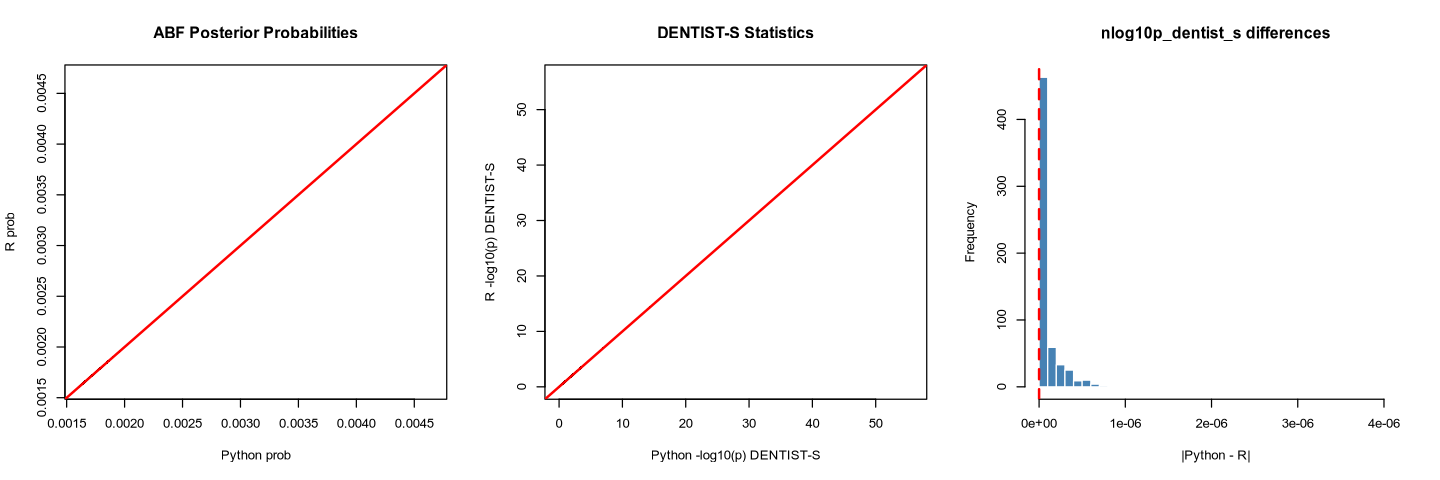

In [6]:
options(repr.plot.width=12, repr.plot.height=4)
par(mfrow=c(1,3))

# Panel 1: prob
plot(py_df$prob, r_df$prob, pch=16, cex=0.4,
     xlab="Python prob", ylab="R prob", main="ABF Posterior Probabilities")
abline(0, 1, col="red", lwd=2)

# Panel 2: nlog10p_dentist_s
plot(py_df$nlog10p_dentist_s[mask], r_df$nlog10p_dentist_s[mask],
     pch=16, cex=0.4,
     xlab="Python -log10(p) DENTIST-S", ylab="R -log10(p) DENTIST-S",
     main="DENTIST-S Statistics")
abline(0, 1, col="red", lwd=2)

# Panel 3: Difference distribution
hist(nlog_diff, breaks=50, col="steelblue", border="white",
     main="nlog10p_dentist_s differences",
     xlab="|Python - R|")
abline(v=0, col="red", lwd=2, lty=2)

## 7. Summary

The pecotmr R implementation of SLALOM matches the original Python implementation across
all computed quantities. Small differences arise from CSV round-trip of the LD matrix
(608×608 doubles lose ~1 ULP precision per element through text serialization):

- **ABF posterior probabilities**: max difference ~6e-10, correlation > 0.999999999999
- **P-values**: max difference ~1e-7, correlation > 0.999999999999
- **DENTIST-S nlog10p**: max difference ~4e-6, correlation > 0.999999999999
- **Outlier flags**: 100% agreement
- **Summary statistics**: lead variant index, n_r2, n_outlier, max_pip, CS sizes all identical

### Bug fix applied

The original R code used two-sided p-values for lead variant selection
(`2 * pnorm(abs(z), lower.tail=FALSE)` selects largest |z|), while the Python original uses
one-sided p-values (`stats.norm.cdf(z)` selects most negative z). This was corrected to
`pnorm(zScore)` in the R implementation. The two approaches agree when the most extreme
z-score happens to be negative, but diverge otherwise.